In [1]:
# !pip install mitsuba

import matplotlib.pyplot as plt # We'll also want to plot some outputs
import os
import trimesh
import open3d as o3d
import numpy as np
from PIL import Image
from scipy.spatial.transform import Rotation

import drjit as dr
import mitsuba as mi
mi.set_variant("cuda_ad_rgb")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
mesh = trimesh.load("results/pointcloud_to_mesh.ply")
components = mesh.split(only_watertight=False)
mesh = max(components, key=lambda m: len(m.faces))
print(f"Kept largest component: {len(mesh.faces)} faces (of {sum(len(c.faces) for c in components)} total)")
mesh.export("results/mesh_cleaned.ply");

In [16]:
# !pip install fast-simplification

mesh = trimesh.load("results/mesh_cleaned.ply")
print("Before:", len(mesh.faces), "faces")
mesh = mesh.simplify_quadric_decimation(face_count=20000)
print("After:", len(mesh.faces), "faces")
mesh.export("results/mesh_decimated.ply");

Before: 2343364 faces
After: 20000 faces


In [2]:
mesh = o3d.io.read_triangle_mesh("results/mesh_decimated.ply")

# Remove non-manifold geometry
mesh.remove_non_manifold_edges()
mesh.remove_duplicated_vertices()
mesh.remove_duplicated_triangles()
mesh.remove_degenerate_triangles()

# Keep only the largest connected component
triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
largest = triangle_clusters == np.argmax(cluster_n_triangles)
mesh.remove_triangles_by_mask(~largest)
mesh.remove_unreferenced_vertices()

o3d.io.write_triangle_mesh("results/mesh_manifold_correct.ply", mesh);

In [3]:
# MESH_PATH = "results/pointcloud_to_mesh.ply"
# MESH_PATH = "results/mesh_cleaned.ply"
# MESH_PATH = "results/mesh_decimated.ply"
MESH_PATH = "results/mesh_manifold_correct.ply"
IMAGE_PATHS = [
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000000.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000010.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000020.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000030.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000040.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000048.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000005.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000015.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000025.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000035.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000045.png",
]
MASK_PATHS = [
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/000.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/010.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/020.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/030.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/040.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/048.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/005.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/015.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/025.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/035.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/045.png",
]
POSE_PATH = "pose_enc_qtf.npz"

images = np.stack([np.array(Image.open(p)) for p in IMAGE_PATHS])/255.0  # (N, H, W, 3)
masks = np.stack([np.array(Image.open(p).convert("L")) for p in MASK_PATHS]) > 127  # (N, H, W) bool
pose = np.load(POSE_PATH)
q   = pose["q"][0]          # (N, 4)  quaternion xyzw
t   = pose["t"][0]          # (N, 3)  translation
f   = pose["f"][0]  # (N, 2)  normalized focal fx, fy

print(q.shape, t.shape, f.shape)
print(images.shape, masks.shape)

(11, 4) (11, 3) (11, 2)
(11, 1200, 1600, 3) (11, 1200, 1600)


In [4]:
def vggt_pose_to_sensor(q_xyzw, t, fov_x_deg, fov_y_deg, width=800, height=600):
    # VGGT: world-to-camera (p_cam = R @ p_world + t)
    R_wc = Rotation.from_quat(q_xyzw).as_matrix()  # (3, 3)
    cam_to_world = np.eye(4)

    # # Invert to camera-to-world
    # cam_to_world[:3, :3] = R_wc.T
    # cam_to_world[:3, 3]  = -R_wc.T @ t
    
    # OpenCV (+Z fwd, Y down) → OpenGL/Mitsuba (-Z fwd, Y up): flip Y and Z columns
    # cam_to_world[:, 1:3] *= -1

    # Invert + flip (theoretically correct)
    R_c2w = R_wc.T
    t_c2w = -R_wc.T @ t
    cam_to_world[:3, :3] = R_c2w
    cam_to_world[:3, 3]  = t_c2w
    # cam_to_world[:3, 1:3] *= -1   # OpenCV → OpenGL
    cam_to_world[:3, 0:2] *= -1

    # print(cam_to_world)

    # No invert + flip
    # cam_to_world[:3, :3] = R_wc
    # cam_to_world[:3, 3]  = t
    # cam_to_world[:3, 1:3] *= -1

    # Invert + no flip (current broken state)
    # cam_to_world[:3, :3] = R_wc.T
    # cam_to_world[:3, 3]  = -R_wc.T @ t
    # (no flip)

    # No invert + no flip
    # cam_to_world[:3, :3] = R_wc
    # cam_to_world[:3, 3]  = t
    # (no flip)

    return mi.load_dict({
        'type': 'perspective',
        'fov': np.degrees(fov_x_deg),
        'fov_axis': 'x',
        'to_world': mi.ScalarTransform4f(cam_to_world.tolist()),
        'film': {
            'type': 'hdrfilm',
            'width': width,
            'height': height,
            'sample_border': True,
        },
        'sampler': {'type': 'independent', 'sample_count': 64},
    })

In [5]:
sensors = [
    vggt_pose_to_sensor(q[i], t[i], f[i, 1], f[i, 0], width=images.shape[2], height=images.shape[1])
    for i in range(len(t))
]

In [6]:
# Create initial grey texture (H x W x 3)
tex_res = 256
texture_np = np.ones((tex_res, tex_res, 3), dtype=np.float32) * 0.5

scene_dict = {
    'type': 'scene',
    'integrator': {
        'type': 'direct_projective',
        # Indirect visibility effects aren't that important here
        # let's turn them off and save some computation time
        'sppi': 0,
        'hide_emitters': True,
    },
    # 'emitter': {
    #     'type': 'envmap',
    #     'filename': "/home/ahc/Datasets/Stanford-ORB/ground_truth/baking_scene001/env_map/0007.exr",
    # },
    'emitter': {
        'type': 'constant',
        'radiance': {'type': 'rgb', 'value': [0.9, 0.9, 1.0]},
    },
    'shape': {
        'type': 'ply',
        'filename': MESH_PATH,
        # 'bsdf': {
        #     'type': 'diffuse',
        #     'reflectance': {'type': 'rgb', 'value': [0.9,0.9,0.9]},  # red
        # },
        'bsdf': {
            'type': 'diffuse',
            'reflectance': {
                'type': 'bitmap',
                'bitmap': mi.Bitmap(texture_np),
                'raw': True,
            }
        }
        # 'bsdf': {
        #     'type': 'twosided',
        #     'material': {
        #         'type': 'diffuse',
        #         'reflectance': {'type': 'rgb', 'value': [0.8, 0.1, 0.1]},
        #     }
        # }
    }
}

# scene_target = mi.load_dict(scene_dict)

In [7]:
images.shape, masks.shape, q.shape, t.shape, f.shape

((11, 1200, 1600, 3), (11, 1200, 1600), (11, 4), (11, 3), (11, 2))

In [8]:
def plot_images(images):
    if len(images[0].shape) == 2:  # greyscale
        fig, axs = plt.subplots(1, len(images), figsize=(20, 5))
        for i in range(len(images)):
            axs[i].imshow(images[i])
            axs[i].axis('off')
    else:
        fig, axs = plt.subplots(1, len(images), figsize=(20, 5))
        for i in range(len(images)):
            axs[i].imshow(mi.util.convert_to_bitmap(images[i]))
            axs[i].axis('off')

In [ ]:
scene_source = mi.load_dict(scene_dict)

init_imgs = [mi.render(scene_source, sensor=sensor, spp=128) for sensor in sensors]
plot_images(init_imgs)

In [ ]:
# init_imgs = [image for image in images]
# print(np.max(images[0]),np.min(images[0]))
plot_images(images)

In [ ]:
mask_imgs = [mask for mask in masks]
plot_images(mask_imgs)

In [ ]:
print(masks[0])

In [ ]:
params = mi.traverse(scene_source)

In [ ]:
print(params)

In [ ]:
opt = mi.ad.Adam(lr=3e-2)
opt['shape.vertex_positions'] = params['shape.vertex_positions']

In [ ]:
for it in range(5):
    total_loss = mi.Float(0.0)

    for sensor, ref_image in zip(sensors, images):
        params.update(opt)

        img = mi.render(scene_source, params, sensor=sensor, seed=it)

        # L2 Loss
        loss = dr.mean(dr.square(img - ref_image))
        dr.backward(loss)

        opt.step()

        total_loss += loss

    print(f"Iteration {1+it:03d}: Loss = {total_loss}", end='\r')

In [ ]:
final_imgs = [mi.render(scene_source, sensor=sensor, spp=128) for sensor in sensors]
plot_images(final_imgs)

In [38]:
# !pip install cholespy

scene_source = mi.load_dict(scene_dict)
params = mi.traverse(scene_source)

In [39]:
lambda_ = 200
ls = mi.ad.LargeSteps(params['shape.vertex_positions'], params['shape.faces'], lambda_)

In [40]:
opt = mi.ad.Adam(lr=1e-1, uniform=True)

In [41]:
opt['u'] = ls.to_differential(params['shape.vertex_positions'])
opt["shape.bsdf.reflectance.data"] = params['shape.bsdf.reflectance.data']

In [ ]:
# mask_f = mi.TensorXf(np.broadcast_to(masks[:, :, :, None].astype(np.float32), images.shape).copy())
# initial_verts = mi.TensorXf(np.array(params['shape.vertex_positions']))


iterations = 20 if 'PYTEST_CURRENT_TEST' not in os.environ else 5
for it in range(iterations):
    total_loss = mi.Float(0.0)

    img_rendering = []
    ref_imgs = []
    for sensor, ref_image, mask in zip(sensors, images, masks):
        # Retrieve the vertex positions from the latent variable
        params['shape.vertex_positions'] = ls.from_differential(opt['u'])
        params['shape.bsdf.reflectance.data'] = opt["shape.bsdf.reflectance.data"]
        params.update()

        img = mi.render(scene_source, params, sensor=sensor, seed=it)
        img_rendering.append(img)
        ref_imgs.append(ref_image)

        mask_f = mi.TensorXf(np.broadcast_to(mask[:, :, None].astype(np.float32), images.shape).copy())


        # L1 Loss
        loss_fg = dr.sum(dr.abs(img - ref_image) * mask_f) / dr.maximum(dr.sum(mask_f), 1.0)
        loss_bg = dr.sum(dr.abs(img) * (1 - mask_f)) / dr.maximum(dr.sum(1 - mask_f), 1.0)
        # loss = dr.mean(dr.abs(img - ref_image))
        loss = loss_fg + loss_bg

        dr.backward(loss)
        opt.step()

        total_loss += loss

        # print(dr.sum(mask_f))
        # print(f"L = {loss}") #, end='\r')
    print(f"Iteration {1+it:03d}: Loss = {total_loss}") #, end='\r')

    # plot_images(img_rendering)
    # plot_images(ref_imgs)


Iteration 001: Loss = [2.62331]
Iteration 002: Loss = [2.49191]
Iteration 003: Loss = [2.40373]
Iteration 004: Loss = [2.31602]
Iteration 005: Loss = [2.28411]


In [43]:
# Update the mesh after the last iteration's gradient step
params['shape.vertex_positions'] = ls.from_differential(opt['u'])
params['shape.bsdf.reflectance.data'] = opt["shape.bsdf.reflectance.data"]
params.update();

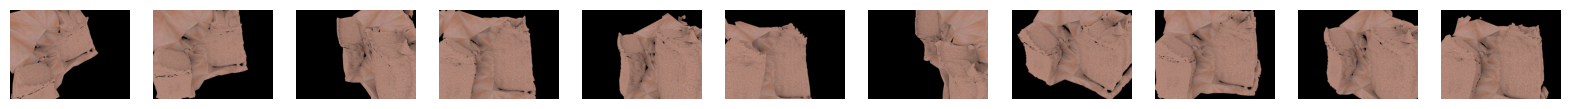

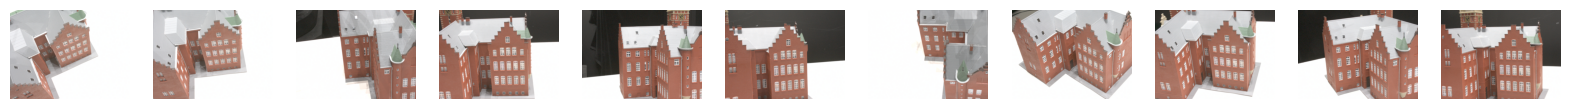

In [44]:
final_imgs = [mi.render(scene_source, sensor=sensor, spp=128) for sensor in sensors]
plot_images(final_imgs)
plot_images(images)


In [20]:
# Load initial mesh
mesh_init = trimesh.load(MESH_PATH)
mesh_init.visual.vertex_colors = [255, 0, 0, 128]  # red, semi-transparent

# Get optimized mesh
verts = np.array(params['shape.vertex_positions']).reshape(-1, 3)
faces = np.array(params['shape.faces']).reshape(-1, 3)
mesh_opt = trimesh.Trimesh(vertices=verts, faces=faces)
mesh_opt.visual.vertex_colors = [0, 255, 0, 128]  # green, semi-transparent

print(f"mesh_init vertices: {len(mesh_init.vertices)}")
print(f"mesh_init  faces:    {len(mesh_init.faces)}")
print(f"mesh_opt  vertices: {len(mesh_opt.vertices)}")
print(f"mesh_opt  faces:    {len(mesh_opt.faces)}")

# Combine and export
combined = trimesh.util.concatenate([mesh_init, mesh_opt])
combined.export("results/mesh_comparison.ply");

mesh_init vertices: 9956
mesh_init  faces:    19949
mesh_opt  vertices: 9956
mesh_opt  faces:    19949


In [ ]:
scene_source

In [ ]:
sensors

In [ ]:
import trimesh
mesh = trimesh.load(MESH_PATH)
print("Mesh bounds:", mesh.bounds)
print("Mesh center:", mesh.centroid)

In [ ]:
print(t)
print(q)

In [ ]:
R0, t0 = extrinsics[0, :3, :3], extrinsics[0, :3, 3]
print("Camera 0 center:", -R0.T @ t0)
print("Mesh bounds:", trimesh.load(MESH_PATH).bounds)
print("Mesh center:", trimesh.load(MESH_PATH).centroid)